# Combined Sweep: Season × Cloud Cover × Classifier

This notebook evaluates all classifiers across seasons and cloud cover thresholds to find the optimal combination.

In [1]:
import os
from dotenv import load_dotenv, find_dotenv
import ee
import geemap

# ── Constants ────────────────────────────────────────────────────────────────

CAMPUS_GEOJSON = {
    "type": "Polygon",
    "coordinates": [
        [
            [80.01710357666015, 23.173962177472703],
            [80.03259601593017, 23.165361215115187],
            [80.03654422760009, 23.172502420044232],
            [80.026802444458, 23.181694681000845],
            [80.01542987823485, 23.176960548201308],
        ]
    ],
}

BANDS = ["B4", "B8", "NDVI"]
SEED = 42

FOREST_POINTS_ASSET = "users/cosypix/forest_points"
NON_FOREST_POINTS_ASSET = "users/cosypix/non_forest_points"

CLASSIFIER_CONFIGS = {
    "rf": {"numberOfTrees": 10, "minLeafPopulation": 3, "bagFraction": 0.7},
    "svm": {"kernelType": "RBF", "gamma": 1,"cost": 1},
    "xgb": {"numberOfTrees": 100 ,"shrinkage": 0.1, "maxNodes": 5},
}

CLASSIFIER_DISPLAY_NAMES = {
    "rf": "Random Forest",
    "svm": "SVM (RBF)",
    "xgb": "Gradient Boosted Trees",
}

def init_ee():
    """Initialize Earth Engine using EE_PROJECT_ID from the .env file."""
    load_dotenv(find_dotenv())
    ee_project = os.getenv("EE_PROJECT_ID")
    if not ee_project:
        raise ValueError("EE_PROJECT_ID not set in .env file")
    ee.Initialize(project=ee_project)
    print("Earth Engine initialized successfully.")

def get_campus_geometry():
    """Return the campus boundary as an ee.Geometry."""
    return ee.Geometry(CAMPUS_GEOJSON)

def mask_s2_clouds(image):
    """Apply Sentinel-2 QA60 cloud/cirrus mask and scale to reflectance."""
    qa = image.select("QA60")
    cloud = 1 << 10
    cirrus = 1 << 11
    mask = qa.bitwiseAnd(cloud).eq(0).And(qa.bitwiseAnd(cirrus).eq(0))
    return image.updateMask(mask).divide(10000)

def build_image(roi, start_date, end_date, cloud_cover=5):
    """Build a cloud-masked Sentinel-2 median composite clipped to *roi*, with NDVI appended."""
    dataset = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_cover))
        .map(mask_s2_clouds)
    )

    image = dataset.median().clip(roi)
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    image = image.addBands(ndvi)
    return image

def load_training_points():
    """Load and merge forest / non-forest training point FeatureCollections."""
    forest_points = ee.FeatureCollection(FOREST_POINTS_ASSET)
    non_forest_points = ee.FeatureCollection(NON_FOREST_POINTS_ASSET)
    training_points = forest_points.merge(non_forest_points)
    return forest_points, non_forest_points, training_points

def sample_and_split(image, training_points, bands=None, seed=None, split=0.7):
    """Sample *image* at *training_points* and split into train/test sets."""
    if bands is None:
        bands = BANDS
    if seed is None:
        seed = SEED

    training = image.select(bands).sampleRegions(
        collection=training_points,
        properties=["label"],
        scale=10,
    )
    training = training.filter(ee.Filter.notNull(bands + ["label"]))
    training = training.randomColumn("random", seed)

    train_set = training.filter(ee.Filter.lt("random", split))
    test_set = training.filter(ee.Filter.gte("random", split))
    return train_set, test_set

def create_classifier(model_type):
    """Return an **untrained** ee.Classifier with canonical hyperparameters."""
    if model_type not in CLASSIFIER_CONFIGS:
        raise ValueError(f"Unknown model_type '{model_type}'. Choose from {list(CLASSIFIER_CONFIGS.keys())}")
    params = CLASSIFIER_CONFIGS[model_type]
    if model_type == "rf":
        return ee.Classifier.smileRandomForest(**params)
    elif model_type == "svm":
        return ee.Classifier.libsvm(**params)
    elif model_type == "xgb":
        return ee.Classifier.smileGradientTreeBoost(**params)

def get_classifier_factories():
    return {
        CLASSIFIER_DISPLAY_NAMES[key]: (lambda k=key: create_classifier(k))
        for key in CLASSIFIER_CONFIGS
    }

def train_model(
    model_type,
    start_date="2026-01-01",
    end_date="2026-02-28",
    cloud_cover=5,
    bands=None,
    seed=None,
    split=0.7,
):
    """Complete training pipeline: build image → sample → split → train."""
    if bands is None:
        bands = BANDS
    if seed is None:
        seed = SEED

    campus = get_campus_geometry()
    image = build_image(campus, start_date, end_date, cloud_cover)

    _, _, training_points = load_training_points()
    train_set, test_set = sample_and_split(
        image, training_points, bands=bands, seed=seed, split=split
    )

    classifier = create_classifier(model_type).train(
        features=train_set,
        classProperty="label",
        inputProperties=bands,
    )

    return classifier, train_set, test_set



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

init_ee()


Earth Engine initialized successfully.


### Campus Boundary

In [3]:
campus = get_campus_geometry()


### Cloud Mask & Helpers

In [4]:
bands = BANDS


### Load Training Points

In [5]:
forest_points, non_forest_points, training_points = load_training_points()

print(f"Forest points:     {forest_points.size().getInfo()}")
print(f"Non-forest points: {non_forest_points.size().getInfo()}")


Forest points:     250
Non-forest points: 250


### Define Seasons & Classifiers

In [6]:
SEASONS = {
    "Early Summer":  ("2025-03-01", "2025-04-30"),
    "Post-Monsoon":  ("2025-09-01", "2025-10-31"),
    "Winter":         ("2025-11-01", "2025-12-31"),
}

CLOUD_COVER_VALUES = [5, 10, 15, 20, 30, 50]
CLASSIFIERS = get_classifier_factories()

print(f"Seasons:     {list(SEASONS.keys())}")
print(f"Classifiers: {list(CLASSIFIERS.keys())}")
print(f"Cloud Cover: {CLOUD_COVER_VALUES}%")


Seasons:     ['Early Summer', 'Post-Monsoon', 'Winter']
Classifiers: ['Random Forest', 'SVM (RBF)', 'Gradient Boosted Trees']
Cloud Cover: [5, 10, 15, 20, 30, 50]%


### Run Season × Classifier Sweep

In [7]:
results = []

for season_name, (start_date, end_date) in SEASONS.items():
    for cc in CLOUD_COVER_VALUES:
        print(f"{'='*60}")
        print(f"  Season: {season_name} | Cloud Cover: {cc}%")
        print(f"{'='*60}")

        # Build the median composite
        dataset = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                   .filterDate(start_date, end_date)
                   .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cc))
                   .map(mask_s2_clouds))

        img_count = dataset.size().getInfo()
        print(f"  Available images: {img_count}")

        if img_count == 0:
            print(f"  ⚠ No images – skipping")
            for clf_name in CLASSIFIERS:
                results.append({
                    'season': season_name, 'cloud_cover': cc, 'classifier': clf_name,
                    'accuracy': None, 'kappa': None, 'image_count': 0,
                })
            continue

        image = dataset.median().clip(campus)

        # Add NDVI
        ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
        image = image.addBands(ndvi)

        # Sample and split 
        train_set, test_set = sample_and_split(image, training_points, bands)

        for clf_name, clf_factory in CLASSIFIERS.items():
            try:
                classifier = clf_factory().train(
                    features=train_set,
                    classProperty='label',
                    inputProperties=bands
                )

                validated = test_set.classify(classifier)
                cm = validated.errorMatrix('label', 'classification')
                accuracy = cm.accuracy().getInfo()
                kappa = cm.kappa().getInfo()
                cm_array = cm.getInfo()

                print(f"  {clf_name:25s}  Accuracy: {accuracy:.4f}   Kappa: {kappa:.4f}")

                results.append({
                    'season': season_name,
                    'cloud_cover': cc,
                    'classifier': clf_name,
                    'accuracy': accuracy,
                    'kappa': kappa,
                    'confusion_matrix': str(cm_array),
                    'image_count': img_count,
                })
            except Exception as e:
                print(f"  {clf_name:25s}  ERROR: {e}")
                results.append({
                    'season': season_name, 'cloud_cover': cc, 'classifier': clf_name,
                    'accuracy': None, 'kappa': None, 'image_count': img_count,
                })

print("✅ Sweep complete!")


  Season: Early Summer | Cloud Cover: 5%
  Available images: 159886
  Random Forest              Accuracy: 0.9375   Kappa: 0.8751
  SVM (RBF)                  Accuracy: 0.9167   Kappa: 0.8334
  Gradient Boosted Trees     Accuracy: 0.9236   Kappa: 0.8473
  Season: Early Summer | Cloud Cover: 10%
  Available images: 204562
  Random Forest              Accuracy: 0.9348   Kappa: 0.8694
  SVM (RBF)                  Accuracy: 0.9348   Kappa: 0.8692
  Gradient Boosted Trees     Accuracy: 0.9275   Kappa: 0.8548
  Season: Early Summer | Cloud Cover: 15%
  Available images: 240530
  Random Forest              Accuracy: 0.9290   Kappa: 0.8580
  SVM (RBF)                  Accuracy: 0.9097   Kappa: 0.8193
  Gradient Boosted Trees     Accuracy: 0.9419   Kappa: 0.8838
  Season: Early Summer | Cloud Cover: 20%
  Available images: 271661
  Random Forest              Accuracy: 0.9275   Kappa: 0.8540
  SVM (RBF)                  Accuracy: 0.8913   Kappa: 0.7829
  Gradient Boosted Trees     Accuracy: 0.92

### Results Table

In [9]:
df = pd.DataFrame(results)
print(df[['season', 'cloud_cover', 'classifier', 'accuracy', 'kappa']].to_string(index=False))
df.to_csv('combined_comparison_results.csv', index=False)
print('\nSaved results to combined_comparison_results.csv')


      season  cloud_cover             classifier  accuracy    kappa
Early Summer            5          Random Forest  0.937500 0.875096
Early Summer            5              SVM (RBF)  0.916667 0.833430
Early Summer            5 Gradient Boosted Trees  0.923611 0.847340
Early Summer           10          Random Forest  0.934783 0.869401
Early Summer           10              SVM (RBF)  0.934783 0.869236
Early Summer           10 Gradient Boosted Trees  0.927536 0.854798
Early Summer           15          Random Forest  0.929032 0.858000
Early Summer           15              SVM (RBF)  0.909677 0.819317
Early Summer           15 Gradient Boosted Trees  0.941935 0.883818
Early Summer           20          Random Forest  0.927536 0.853968
Early Summer           20              SVM (RBF)  0.891304 0.782882
Early Summer           20 Gradient Boosted Trees  0.927536 0.853968
Early Summer           30          Random Forest  0.966887 0.933486
Early Summer           30              SVM (RBF)

### Overall Best Configuration

In [10]:
print("="*60)
print("  🏆 OVERALL BEST CONFIGURATION 🏆")
print("="*60)
valid_df = df.dropna(subset=['accuracy'])
if not valid_df.empty:
    best = valid_df.loc[valid_df['accuracy'].idxmax()]
    print(f"Best Season:      {best['season']}")
    print(f"Best Cloud Cover: {best['cloud_cover']}%")
    print(f"Best Classifier:  {best['classifier']}")
    print(f"Accuracy:         {best['accuracy']:.4f}")
    print(f"Kappa:            {best['kappa']:.4f}")
else:
    print("No valid results to display.")


  🏆 OVERALL BEST CONFIGURATION 🏆
Best Season:      Winter
Best Cloud Cover: 10%
Best Classifier:  SVM (RBF)
Accuracy:         1.0000
Kappa:            1.0000


=== Top 3 Results per Model ===

Random Forest


,season,cloud_cover,accuracy,kappa
0,Post-Monsoon,15,0.984496,0.968998
1,Winter,10,0.978873,0.957289
2,Winter,5,0.976562,0.952987
3,Winter,50,0.972973,0.945598
4,Winter,15,0.970588,0.941144




SVM (RBF)


,season,cloud_cover,accuracy,kappa
0,Winter,20,0.976048,0.951326
1,Winter,50,0.972973,0.945598
2,Winter,5,0.968750,0.937132
3,Post-Monsoon,20,0.964789,0.929577
4,Winter,30,0.962963,0.925835




Gradient Boosted Trees


,season,cloud_cover,accuracy,kappa
0,Post-Monsoon,15,0.976744,0.953480
1,Winter,20,0.976048,0.951475
2,Winter,50,0.972973,0.945598
3,Winter,10,0.971831,0.942949
4,Early Summer,50,0.968153,0.936288


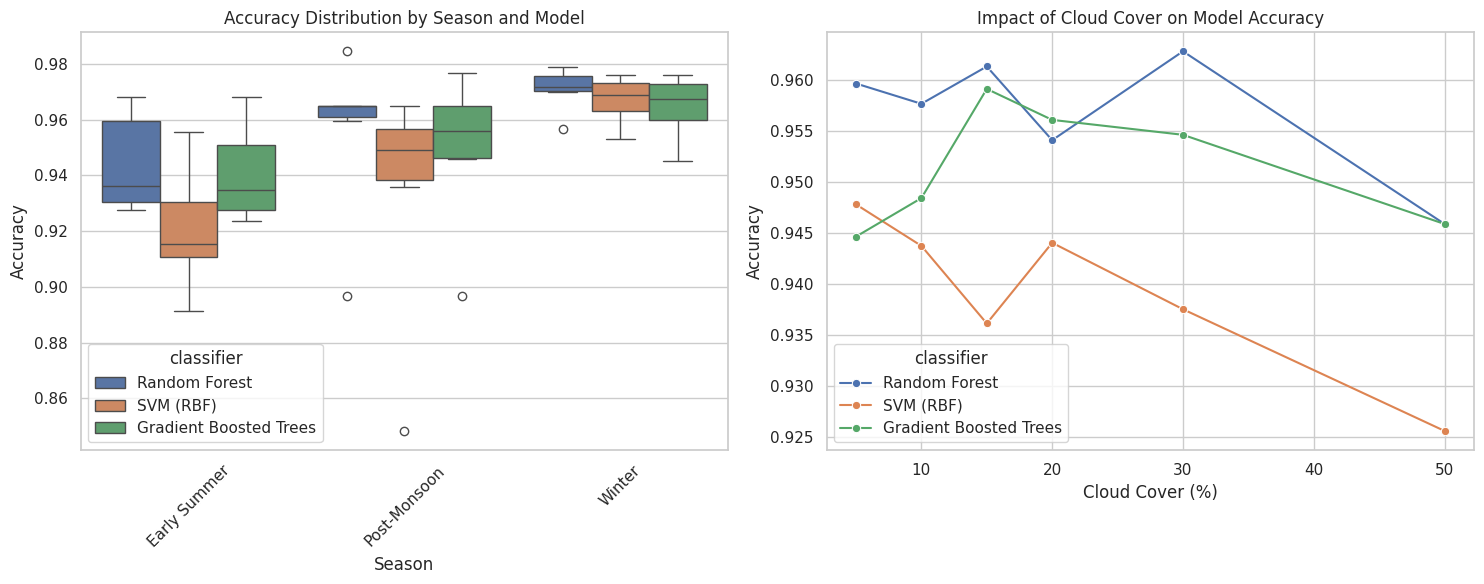

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load the combined results
df = pd.read_csv('combined_comparison_results.csv')

# Filter out 100% accuracy results as they are likely anomalies
df_filtered = df[df['accuracy'] < 0.9999]

print("=== Top 3 Results per Model ===\n")
for clf in df_filtered['classifier'].unique():
    subset = df_filtered[df_filtered['classifier'] == clf]
    top3 = subset.sort_values(by=['accuracy', 'kappa'], ascending=[False, False]).head(5)
    
    print(f"\033[1m{clf}\033[0m")
    display(top3[['season', 'cloud_cover', 'accuracy', 'kappa']].reset_index(drop=True))
    print("\n")

# --- Visualizations ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Accuracy Distribution among Seasons
sns.boxplot(data=df_filtered, x='season', y='accuracy', hue='classifier', ax=axes[0])
axes[0].set_title('Accuracy Distribution by Season and Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Season')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Impact of Cloud Cover on Accuracy
try:
    sns.lineplot(data=df_filtered, x='cloud_cover', y='accuracy', hue='classifier', marker='o', errorbar=None, ax=axes[1])
except TypeError:
    # Fallback for older seaborn versions
    sns.lineplot(data=df_filtered, x='cloud_cover', y='accuracy', hue='classifier', marker='o', ci=None, ax=axes[1])

axes[1].set_title('Impact of Cloud Cover on Model Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Cloud Cover (%)')

plt.tight_layout()
plt.show()


In [3]:
# Group by season and cloud_cover to find the average score across all models
intersection_scores = df_filtered.groupby(['season', 'cloud_cover']).agg(
    avg_accuracy=('accuracy', 'mean'),
    avg_kappa=('kappa', 'mean'),
    model_count=('classifier', 'nunique') # Count unique models per combination
).reset_index()

# Ensure we're only looking at combinations where all 3 models were evaluated
intersection_scores = intersection_scores[intersection_scores['model_count'] >= 3]

# Retrieve the combination with the highest average accuracy
best_intersection = intersection_scores.sort_values(by=['avg_accuracy', 'avg_kappa'], ascending=[False, False]).iloc[0]

print("=== Best Overall (Intersection) Condition ===")
print(f"Season:       {best_intersection['season']}")
print(f"Cloud Cover:  {best_intersection['cloud_cover']}%")
print(f"Average Acc:  {best_intersection['avg_accuracy']:.4f}")
print(f"Average Kap:  {best_intersection['avg_kappa']:.4f}\n")

# Show how each individual model performed under these exact winning conditions
print("=== Individual Model Performances on this Condition ===")
winning_subset = df_filtered[
    (df_filtered['season'] == best_intersection['season']) & 
    (df_filtered['cloud_cover'] == best_intersection['cloud_cover'])
]
display(winning_subset[['classifier', 'accuracy', 'kappa']].reset_index(drop=True))


=== Best Overall (Intersection) Condition ===
Season:       Winter
Cloud Cover:  20%
Average Acc:  0.9741
Average Kap:  0.9474

=== Individual Model Performances on this Condition ===


,classifier,accuracy,kappa
0,Random Forest,0.970060,0.939436
1,SVM (RBF),0.976048,0.951326
2,Gradient Boosted Trees,0.976048,0.951475
